In [14]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
RESULTS_DIR   = "/path/to/results"   # ← set this
N_PER_STRAND  = 2000
N_RANDOM_DRAWS = 1000   # large → smooth control curve
SEED          = 10


In [16]:
def load_results(results_dir):
    files = sorted(glob.glob(os.path.join(results_dir, "cohesion_tad_*.npy")))
    if not files:
        raise FileNotFoundError(f"No cohesion_tad_*.npy files found in {results_dir}")
    print(f"Loading {len(files)} instance files …")

    index_dists = []
    n_not_found = 0

    for fpath in files:
        result = np.load(fpath, allow_pickle=True).item()
        for dsb_res in result["dsb_results"]:
            if not dsb_res["found"]:
                n_not_found += 1
                continue

            cohesion_idx = dsb_res["cohesion_indices"]   # (n_ep,)
            tad_idx      = dsb_res["tad_indices"]         # (4,)

            d = np.min(np.abs(cohesion_idx[:, None] - tad_idx[None, :]))
            index_dists.append(d)

    print(f"  Binding events found : {len(index_dists)}")
    print(f"  No sister cohesion   : {n_not_found}")
    return np.array(index_dists)


# Random control

def build_random_control(results_dir, n_draws, seed):
    """
    For each DSB sub-instance with a valid result, draw positions uniformly
    from the full sister chromatid and compute min distance to that instance's
    TAD boundaries.  The draws are pooled across all instances.
    """
    N = N_PER_STRAND * 2

    rng   = np.random.default_rng(seed)
    files = sorted(glob.glob(os.path.join(results_dir, "cohesion_tad_*.npy")))

    all_tad_idx = []
    for fpath in files:
        result = np.load(fpath, allow_pickle=True).item()
        for dsb_res in result["dsb_results"]:
            if dsb_res["found"]:
                all_tad_idx.append(dsb_res["tad_indices"])

    if not all_tad_idx:
        return np.array([])

    n_per_instance = max(1, n_draws // len(all_tad_idx))
    ctrl = []
    for i, tad_idx in enumerate(all_tad_idx):
        # tad_idx is in global space; recover which sub-instance and draw
        # from its sister chromatid window [i*N + N_PER_STRAND, (i+1)*N)
        dsb_i_approx = int(tad_idx[0]) // N 
        rand_lo = dsb_i_approx * N + N_PER_STRAND
        rand_hi = (dsb_i_approx + 1) * N
        rand_pos = rng.integers(rand_lo, rand_hi, size=n_per_instance)
        dists = np.min(np.abs(rand_pos[:, None] - tad_idx[None, :]), axis=1)
        ctrl.append(dists)

    return np.concatenate(ctrl)

In [17]:
index_dists = load_results(RESULTS_DIR)
print(f"\nIndex-space — mean: {index_dists.mean():.1f}, "
        f"median: {np.median(index_dists):.1f}")

ctrl_dists = build_random_control(RESULTS_DIR, N_RANDOM_DRAWS, SEED)

Loading 50 instance files …
  Binding events found : 500
  No sister cohesion   : 0

Index-space — mean: 110.7, median: 58.0


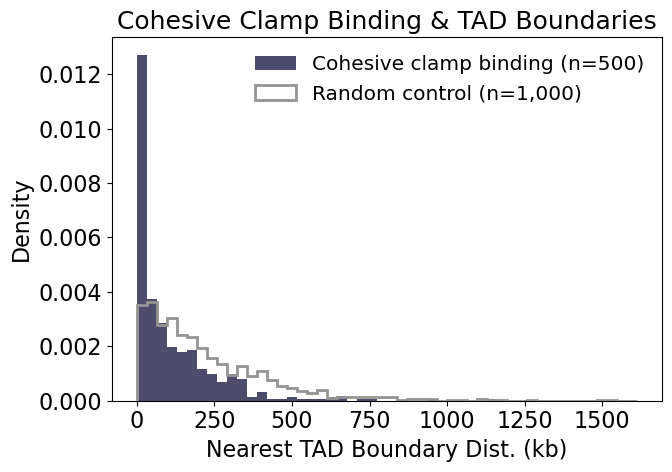

In [18]:
n_bins = 50

plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'axes.titlesize': 18})
plt.rcParams.update({'legend.fontsize': 14.5})

fig, ax = plt.subplots(figsize=(7, 5))

combined_max = max(index_dists.max(), ctrl_dists.max()) if len(ctrl_dists) else index_dists.max()
bins = np.linspace(0, combined_max * 1.05, n_bins + 1)

ax.hist(
    index_dists,
    bins=bins,
    density=True,
    alpha=0.7,
    color="xkcd:dark navy blue",
    label=f"Cohesive clamp binding (n={len(index_dists)})"
)

if len(ctrl_dists):
    ax.hist(
        ctrl_dists,
        bins=bins,
        density=True,
        histtype="step",      # outline instead of filled
        linewidth=2,
        color="xkcd:gray",
        label=f"Random control (n={len(ctrl_dists):,})"
    )

ax.set_xlabel("Nearest TAD Boundary Dist. (kb)")
ax.set_ylabel("Density")
ax.set_title(
    "Cohesive Clamp Binding & TAD Boundaries"
)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### T_50

In [ ]:
files = glob.glob("/path/to/run_bundle_*.npz")

all_fpt = []
all_coh = []

for f in files:
    d = np.load(f, allow_pickle=True)

    for i in range(d["fpt"].shape[0]):
        all_fpt.append(d["fpt"][i])
        all_coh.append(d["cohesion"][i])

In [20]:
TAD_WINDOW = 50
HOMOLOGY = 3000
EQ = 1030


def classify(d):

    near_flags = []

    for side in ["left", "right"]:

        if d[side] is None:
            continue

        coh = d[side]["sister_indices"]

        dist = np.min(np.abs(d["tad_global"][:, None] - coh[None, :]))

        near_flags.append(dist <= TAD_WINDOW)

    n_near = sum(near_flags)

    if n_near == 0:
        return 0
    elif n_near == 1:
        return 1
    else:
        return 2

def classify_first(d):

    candidates = []

    for side in ["left", "right"]:
        if d.get(side) is not None:
            candidates.append(d[side])

    if len(candidates) == 0:
        return 0  # no binding at all

    # first binding event = earliest t_first
    first_event = min(candidates, key=lambda x: x["t_first"])

    coh = first_event["sister_indices"]

    # distance to nearest TAD boundary
    dist = np.min(np.abs(d["tad_global"][:, None] - coh[None, :]))

    return 1 if dist <= TAD_WINDOW else 0

def weibull(x, k, lam):
    return 1 - np.exp(-(x / lam)**k)

def compute_t50(data, return_curve=False):

    xs, ys = [], []

    for t in range(20000):
        xs.append(t * 2/3)
        ys.append(np.mean(data[:, HOMOLOGY] < t + EQ))

    xs = np.array(xs)
    ys = np.array(ys)

    popt, _ = curve_fit(weibull, xs, ys, p0=[0.5, 1000], maxfev=20000)

    k, lam = popt
    t50 = lam * np.log(2)**(1/k)

    if return_curve:
        return k, lam, t50, xs, ys
    return k, lam, t50

def compute_t50_from_dt(dt, return_curve=False):
    dt = np.array(dt) * (2/3) 
    xs = np.linspace(0, np.max(dt), 500)
    ys = np.array([np.mean(dt < x) for x in xs])
    popt, _ = curve_fit(weibull, xs, ys, p0=[0.7, np.median(dt)], maxfev=20000)
    k, lam = popt
    t50 = lam * np.log(2)**(1/k)
    if return_curve:
        return k, lam, t50, xs, ys
    return k, lam, t50


In [21]:
classes = np.array([classify(c) for c in all_coh])

groups = {0: [], 1: [], 2: []}

for i in range(len(all_fpt)):
    groups[classes[i]].append(all_fpt[i])

for k in groups:
    groups[k] = np.array(groups[k])

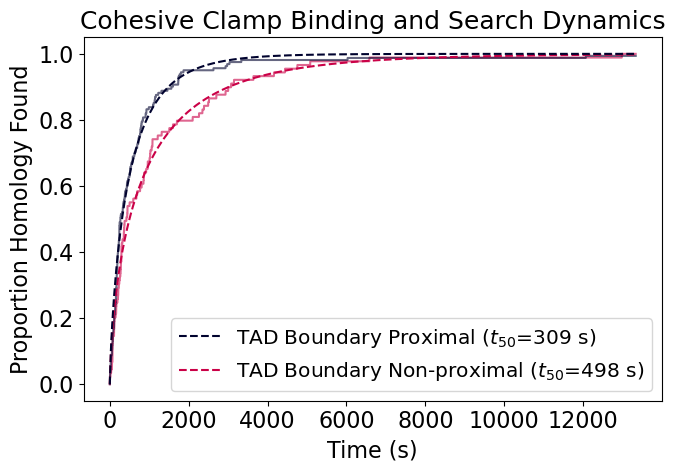

In [22]:
groups_combined = {
    "none": groups[0],
    "any": np.concatenate([groups[1], groups[2]]) if len(groups[1]) + len(groups[2]) > 0 else np.array([])
}

plt.figure(figsize=(7,5))

if len(groups_combined["none"]) > 0 and len(groups_combined["any"]) > 0:

    k0, l0, t0, xs0, ys0 = compute_t50(groups_combined["none"], return_curve=True)
    k1, l1, t1, xs1, ys1 = compute_t50(groups_combined["any"], return_curve=True)

    # raw
    plt.plot(xs0, ys0, color="xkcd:ruby", alpha=0.6)
    plt.plot(xs1, ys1, color="xkcd:dark navy blue", alpha=0.6)

    # fits
    xfit = np.linspace(0, xs0.max(), 500)

    plt.plot(
        xfit, weibull(xfit, k0, l0),
        color="xkcd:ruby",
        linestyle='--',
        label=f"TAD Boundary Non-proximal ($t_{{50}}$={t0:.0f} s)"
    )

    plt.plot(
        xfit, weibull(xfit, k1, l1),
        color="xkcd:dark navy blue",
        linestyle='--',
        label=f"TAD Boundary Proximal ($t_{{50}}$={t1:.0f} s)"
    )


plt.xlabel("Time (s)")
plt.ylabel("Proportion Homology Found")
plt.title("Cohesive Clamp Binding and Search Dynamics")
plt.legend(reverse=True)
plt.tight_layout()
plt.show()

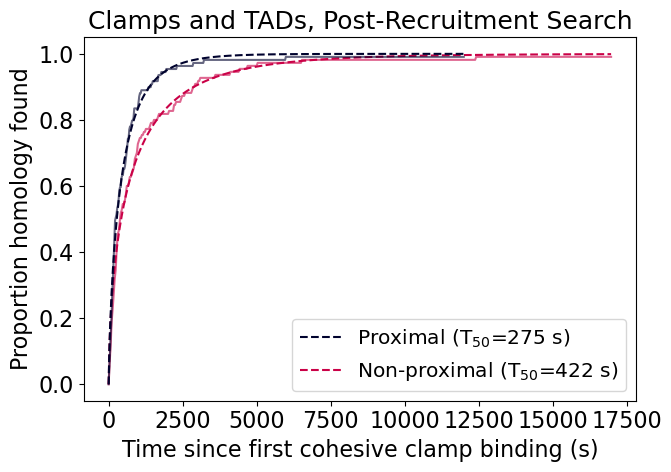

In [23]:
# time from cohesive clamp binding

all_dt = []
all_cls = []

for i, d in enumerate(all_coh):
    if isinstance(d, list):
        dsb_list = d
    else:
        dsb_list = [d]

    for d in dsb_list:
        if not isinstance(d, dict):
            continue

        c = classify_first(d)

        t_candidates = []
        for side in ["left", "right"]:
            if d.get(side) is not None:
                t_candidates.append(d[side]["t_first"])
        if len(t_candidates) == 0:
            continue
        t_bind = min(t_candidates)

        t_hom = all_fpt[i][HOMOLOGY]
        if not np.isfinite(t_hom):
            continue

        dt = t_hom - t_bind
        if dt < 0:
            continue

        all_dt.append(dt)
        all_cls.append(c)

all_dt  = np.array(all_dt)
all_cls = np.array(all_cls)

groups = {
    0: all_dt[all_cls == 0],
    1: all_dt[all_cls == 1],
}
groups_labeled = {
    "nonproximal": groups[0],
    "proximal": groups[1]
}

plt.figure(figsize=(7,5))

colors = {
    "nonproximal": "xkcd:ruby",
    "proximal": "xkcd:dark navy blue"
}

labels = {
    "nonproximal": "Non-proximal",
    "proximal": "Proximal"
}

for key in ["nonproximal", "proximal"]:

    dt = groups_labeled[key] if key in groups_labeled else groups[key]

    if len(dt) == 0:
        continue

    k, lam, t50, xs, ys = compute_t50_from_dt(dt, return_curve=True)

    # raw CDF
    plt.plot(xs, ys, color=colors[key], alpha=0.6)

    # Weibull fit
    xfit = np.linspace(0, xs.max(), 500)
    plt.plot(
        xfit,
        weibull(xfit, k, lam),
        linestyle="--",
        color=colors[key],
        label=f"{labels[key]} (T$_{{50}}$={t50:.0f} s)"
    )

plt.xlabel("Time since first cohesive clamp binding (s)")
plt.ylabel("Proportion homology found")
plt.title("Clamps and TADs, Post-Recruitment Search")
plt.legend(reverse = True)
plt.tight_layout()
plt.show()